In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
folder_path = '/mnt/d/DataSets/Give Me Some Credit/'

df = pd.read_csv(f'{folder_path}cs-training.csv')

In [3]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
df.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [5]:
df = df.drop('Unnamed: 0', axis=1)

### Разделение на выборки

In [6]:
def plt_pie(df, col):
    counts = df[col].value_counts().sort_index()
    plt.figure(figsize=[4, 4])
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
    plt.title(col)
    plt.show()

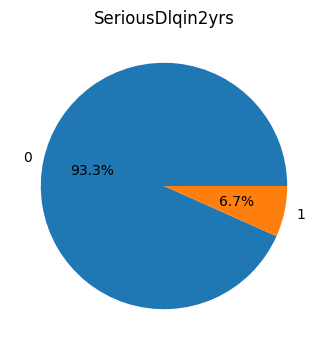

In [7]:
plt_pie(df, 'SeriousDlqin2yrs')

In [8]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df['SeriousDlqin2yrs'],
    shuffle=True, 
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5, 
    stratify=temp_df['SeriousDlqin2yrs'],
    shuffle=True, 
    random_state=42
)

### Обработка пропусков

In [9]:
print(train_df.isnull().sum())

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           20723
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       2721
dtype: int64


In [10]:
print(val_df.isnull().sum())

SeriousDlqin2yrs                           0
RevolvingUtilizationOfUnsecuredLines       0
age                                        0
NumberOfTime30-59DaysPastDueNotWorse       0
DebtRatio                                  0
MonthlyIncome                           4498
NumberOfOpenCreditLinesAndLoans            0
NumberOfTimes90DaysLate                    0
NumberRealEstateLoansOrLines               0
NumberOfTime60-89DaysPastDueNotWorse       0
NumberOfDependents                       586
dtype: int64


In [11]:
print(test_df.isnull().sum())

SeriousDlqin2yrs                           0
RevolvingUtilizationOfUnsecuredLines       0
age                                        0
NumberOfTime30-59DaysPastDueNotWorse       0
DebtRatio                                  0
MonthlyIncome                           4510
NumberOfOpenCreditLinesAndLoans            0
NumberOfTimes90DaysLate                    0
NumberRealEstateLoansOrLines               0
NumberOfTime60-89DaysPastDueNotWorse       0
NumberOfDependents                       617
dtype: int64


In [12]:
median_MonthlyIncome = train_df['MonthlyIncome'].median()

for df_ in [train_df, val_df, test_df]:
    df_['MonthlyIncome_is_nan'] = df_['MonthlyIncome'].isna().astype(int)

for df_ in [train_df, val_df, test_df]:
    df_['MonthlyIncome'] = df_['MonthlyIncome'].fillna(median_MonthlyIncome)

In [13]:
median_NumberOfDependents = train_df['NumberOfDependents'].median()

for df_ in [train_df, val_df, test_df]:
    df_['NumberOfDependents_is_nan'] = df_['NumberOfDependents'].isna().astype(int)

for df_ in [train_df, val_df, test_df]:
    df_['NumberOfDependents'] = df_['NumberOfDependents'].fillna(median_NumberOfDependents)

In [14]:
train_df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_is_nan,NumberOfDependents_is_nan
138985,0,0.000000,49,0,0.127227,5163.0,5,0,0,0,0.0,0,0
63964,0,0.033105,37,0,0.423063,2800.0,4,0,1,0,1.0,0,0
46077,0,0.007948,39,0,0.685663,3333.0,11,0,1,0,0.0,0,0
83030,0,0.576297,57,0,0.320077,15161.0,14,0,4,0,0.0,0,0
11184,0,0.623724,35,0,0.534226,6500.0,9,0,3,0,1.0,0,0


### Очистка выбросов

In [15]:
def plot_feature(df, col):
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    
    sns.violinplot(x=df[col], orient='h', ax=axes[0])
    axes[0].set_title(f'{col}')
    
    sns.kdeplot(
        data=df,
        x=col,
        hue='SeriousDlqin2yrs',
        fill=True,
        common_norm=False,
        alpha=0.4,
        ax=axes[1]
    )
    axes[1].set_title(f'{col} vs target')
    
    plt.tight_layout()
    plt.show()

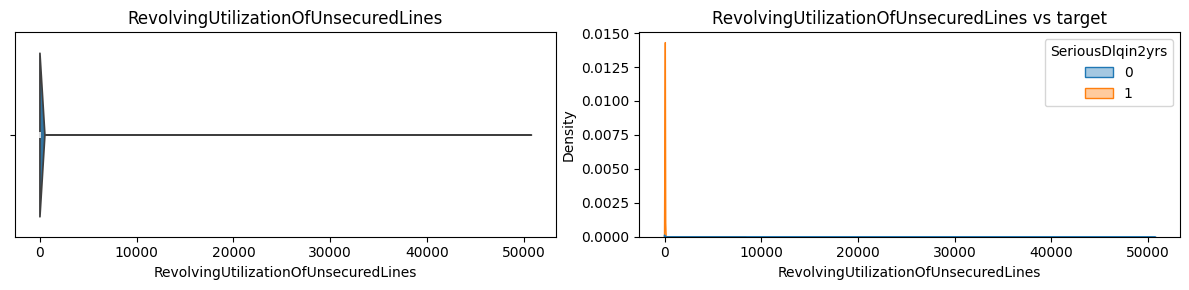

In [16]:
plot_feature(train_df, 'RevolvingUtilizationOfUnsecuredLines')

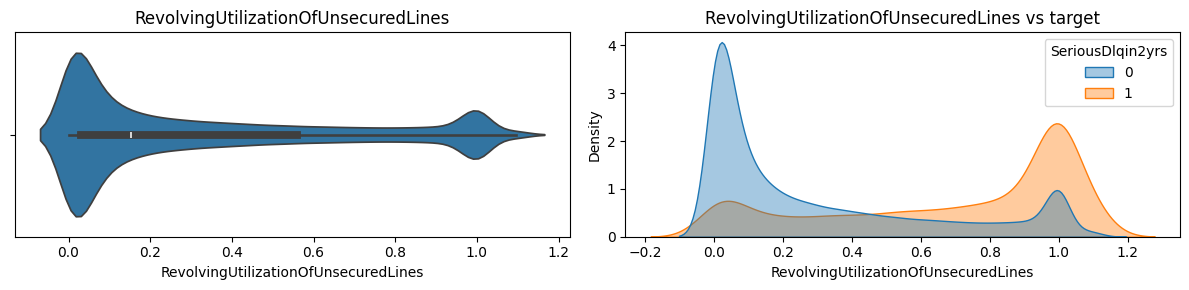

In [17]:
col = 'RevolvingUtilizationOfUnsecuredLines'

high = train_df[col].quantile(0.99)

buf_df = train_df.copy()
buf_df[col] = buf_df[col].clip(upper=high)

plot_feature(buf_df, col)

In [18]:
for df_ in [train_df, val_df, test_df]:
    df_['Revolving_high'] = (df_['RevolvingUtilizationOfUnsecuredLines'] > 0.8).astype(int)
    df_['Revolving_excess'] = (df_['RevolvingUtilizationOfUnsecuredLines'] > 1).astype(int)
    df_['RevolvingUtilizationOfUnsecuredLines'] = df_['RevolvingUtilizationOfUnsecuredLines'].clip(upper=1)

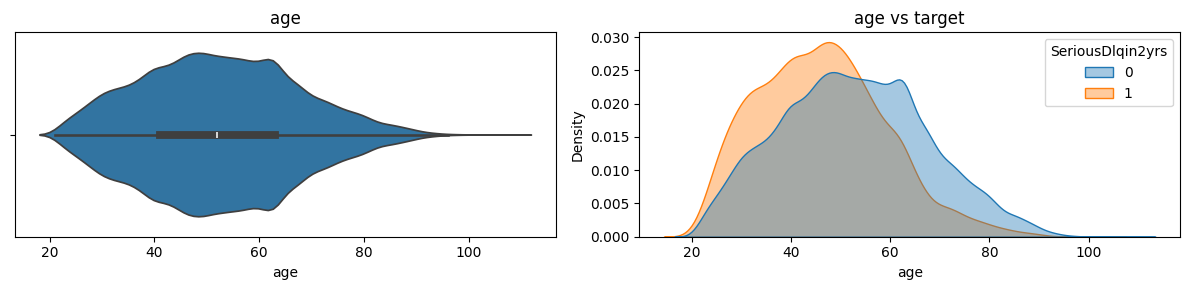

In [19]:
plot_feature(train_df, 'age')

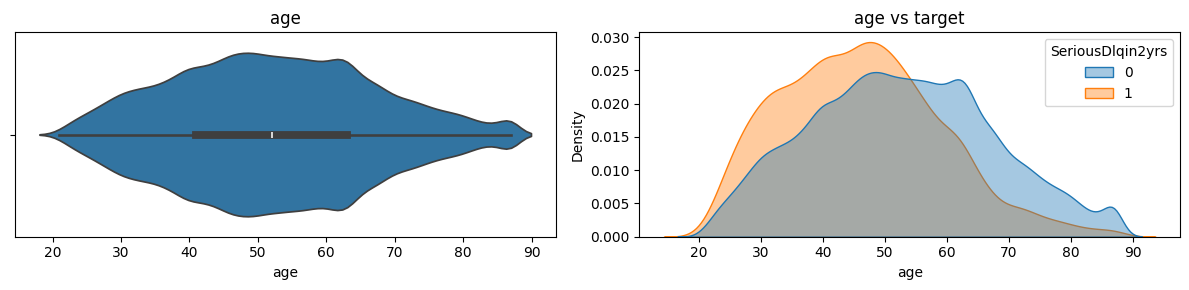

In [20]:
col = 'age'

high = train_df[col].quantile(0.99)

buf_df = train_df.copy()
buf_df[col] = buf_df[col].clip(upper=high)

plot_feature(buf_df, col)

In [21]:
train_df = buf_df.copy()

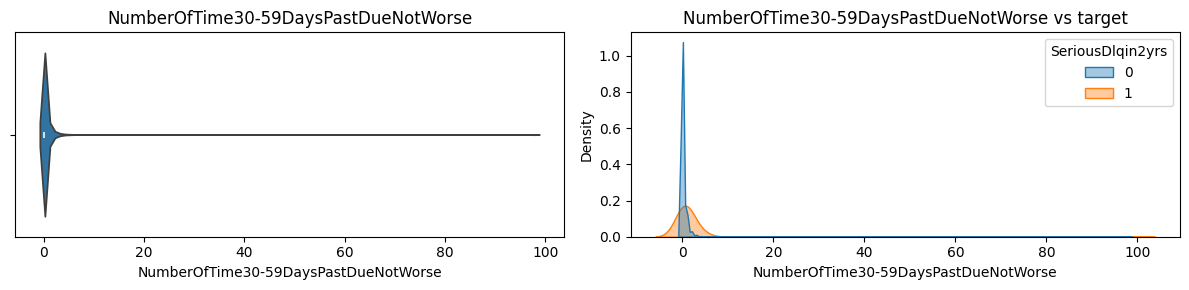

In [22]:
plot_feature(train_df, 'NumberOfTime30-59DaysPastDueNotWorse')

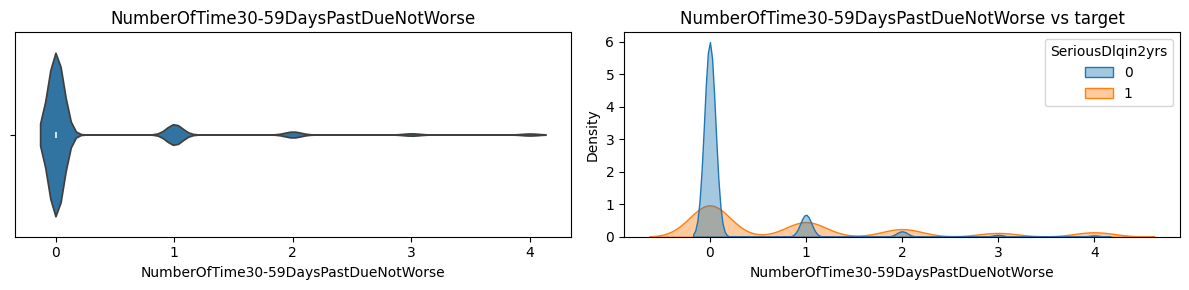

In [23]:
col = 'NumberOfTime30-59DaysPastDueNotWorse'

high = train_df[col].quantile(0.99)

buf_df = train_df.copy()
buf_df[col] = buf_df[col].clip(upper=high)

plot_feature(buf_df, col)

In [24]:
train_df = buf_df.copy()

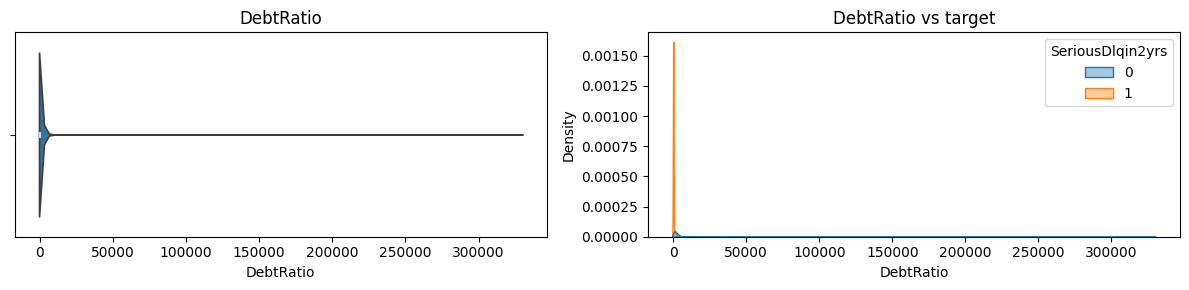

In [25]:
plot_feature(train_df, 'DebtRatio')

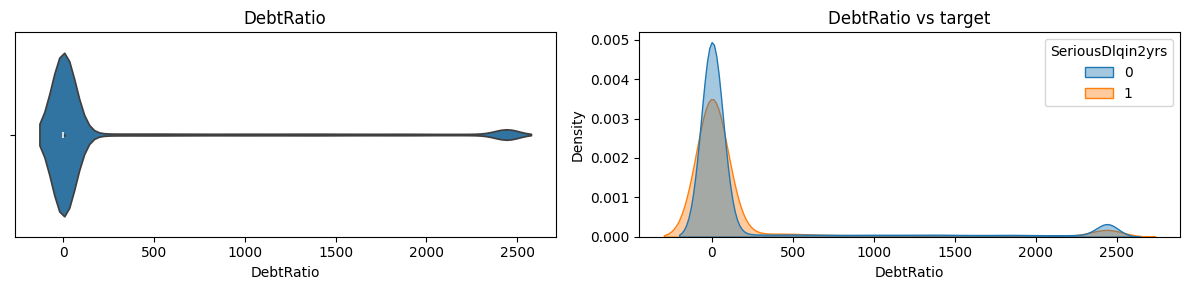

In [26]:
col = 'DebtRatio'

high = train_df[col].quantile(0.95)

buf_df = train_df.copy()
buf_df[col] = buf_df[col].clip(upper=high)

plot_feature(buf_df, col)

In [27]:
buf_df[buf_df['MonthlyIncome_is_nan'] == 1]['DebtRatio'].describe()

count    20723.000000
mean      1211.889963
std        970.300676
min          0.000000
25%        125.000000
50%       1170.000000
75%       2388.500000
max       2444.050000
Name: DebtRatio, dtype: float64

In [28]:
buf_df = train_df.copy()

buf_df['DebtRatio_with_income'] = buf_df[buf_df['MonthlyIncome_is_nan'] == 0]['DebtRatio']
buf_df['DebtRatio_nan_income'] = buf_df[buf_df['MonthlyIncome_is_nan'] == 1]['DebtRatio']

debt_cols = ['DebtRatio', 'MonthlyIncome_is_nan', 'DebtRatio_with_income', 'DebtRatio_nan_income']

buf_df[debt_cols].head(20)

,DebtRatio,MonthlyIncome_is_nan,DebtRatio_with_income,DebtRatio_nan_income
138985,0.127227,0,0.127227,NaN
63964,0.423063,0,0.423063,NaN
46077,0.685663,0,0.685663,NaN
83030,0.320077,0,0.320077,NaN
11184,0.534226,0,0.534226,NaN
145869,0.114949,0,0.114949,NaN
59705,88.000000,1,NaN,88.0
76753,1089.000000,1,NaN,1089.0
15447,0.040381,0,0.040381,NaN
23013,0.318934,0,0.318934,NaN


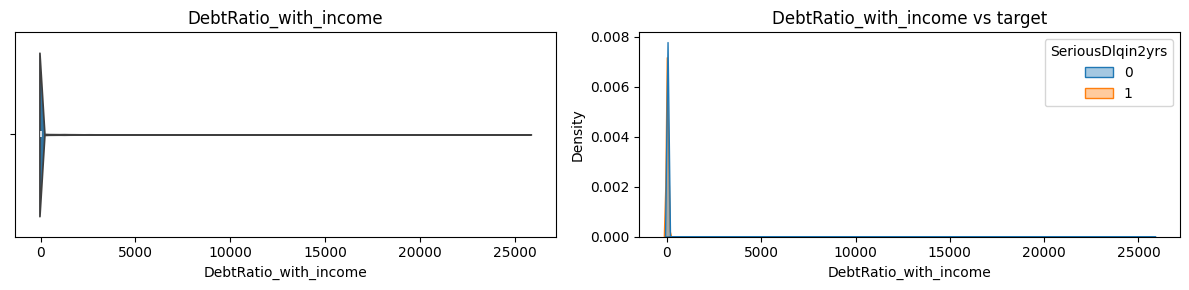

In [29]:
plot_feature(buf_df, 'DebtRatio_with_income')

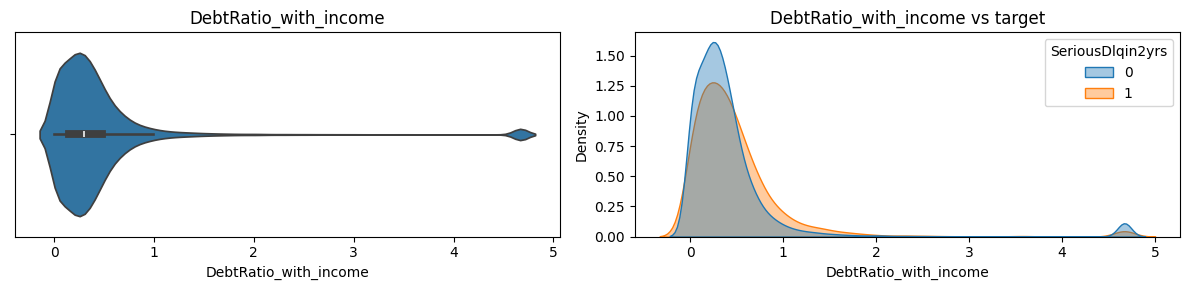

In [30]:
col = 'DebtRatio_with_income'

high = buf_df[col].quantile(0.98)

buf2_df = buf_df.copy()
buf2_df[col] = buf2_df[col].clip(upper=high)

plot_feature(buf2_df, col)

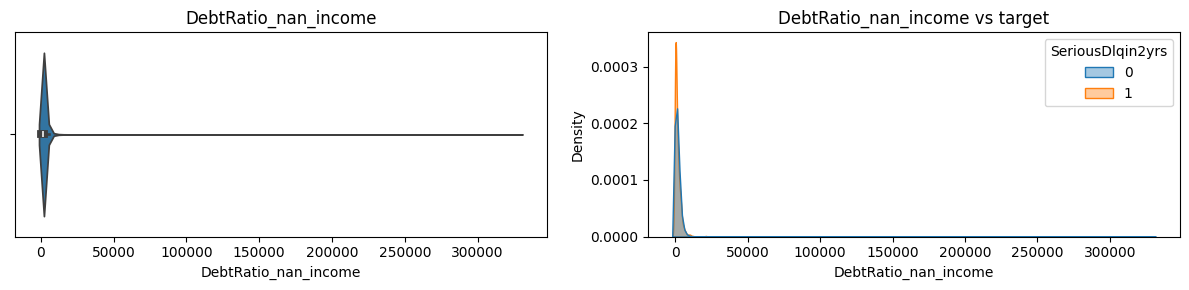

In [31]:
plot_feature(buf_df, 'DebtRatio_nan_income')

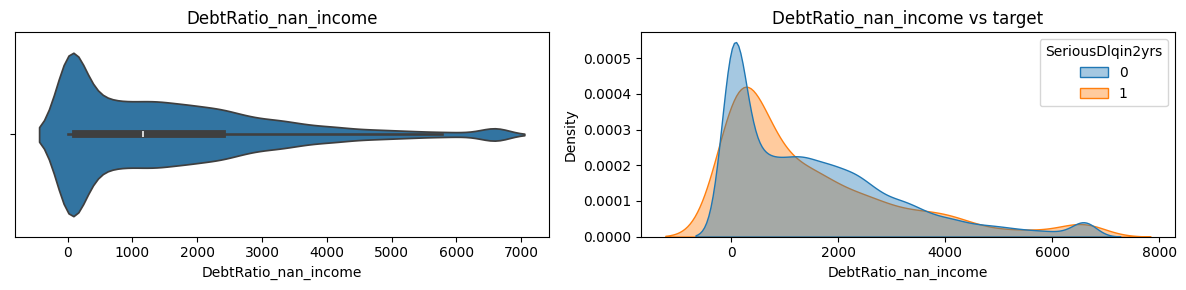

In [32]:
col = 'DebtRatio_nan_income'

high = buf_df[col].quantile(0.98)

buf2_df = buf_df.copy()
buf2_df[col] = buf2_df[col].clip(upper=high)

plot_feature(buf2_df, col)

In [33]:
col = 'DebtRatio'

buf_df = train_df.copy()

buf_df['DebtRatio_high'] = (buf_df[col] > 1).astype(int)

high = 1
buf_df[col] = buf_df[col].clip(upper=high)

In [34]:
buf_df[['DebtRatio', 'DebtRatio_high', 'MonthlyIncome_is_nan']].head(20)

,DebtRatio,DebtRatio_high,MonthlyIncome_is_nan
138985,0.127227,0,0
63964,0.423063,0,0
46077,0.685663,0,0
83030,0.320077,0,0
11184,0.534226,0,0
145869,0.114949,0,0
59705,1.000000,1,1
76753,1.000000,1,1
15447,0.040381,0,0
23013,0.318934,0,0


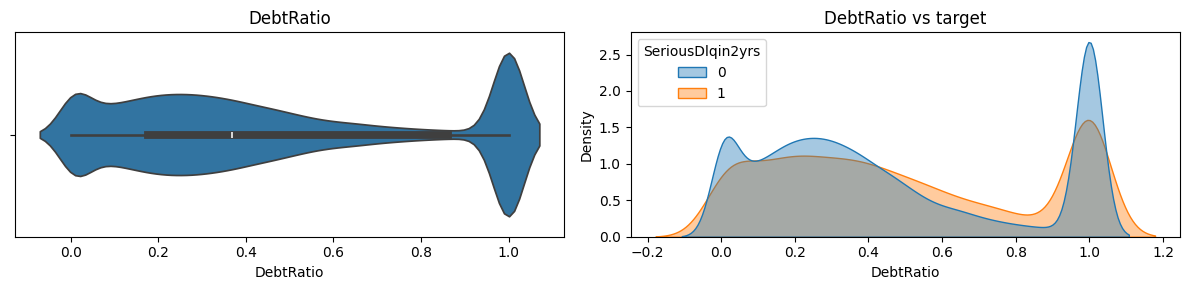

In [35]:
plot_feature(buf_df, 'DebtRatio')

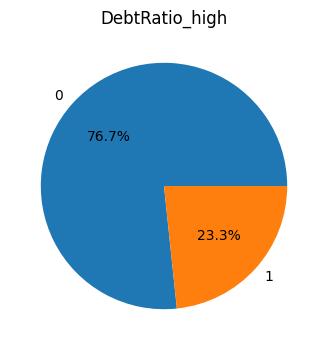

In [36]:
plt_pie(buf_df, 'DebtRatio_high')

In [37]:
for df_ in [train_df, val_df, test_df]:
    df_['DebtRatio_high'] = (df_['DebtRatio'] > 1).astype(int)
    df_['DebtRatio'] = df_['DebtRatio'].clip(upper=1)

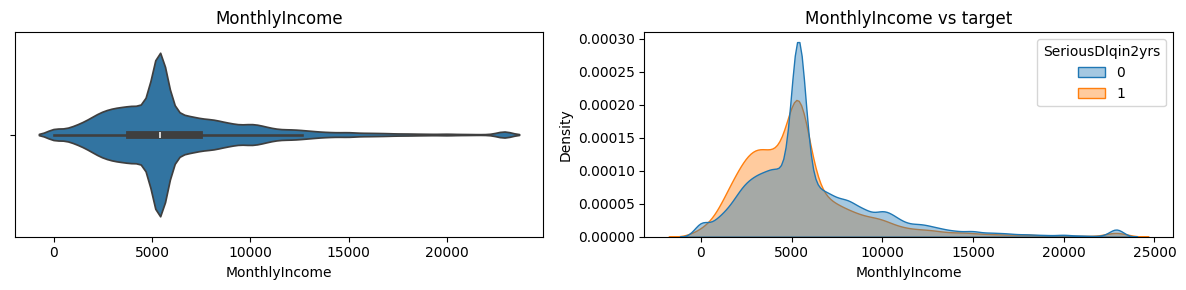

In [38]:
col = 'MonthlyIncome'

high = train_df[col].quantile(0.99)

buf_df = train_df.copy()
buf_df[col] = buf_df[col].clip(upper=high)

plot_feature(buf_df, col)

In [39]:
buf_df['MonthlyIncome'].value_counts().head(10)

MonthlyIncome
5382.0     20726
5000.0      1929
4000.0      1451
6000.0      1320
3000.0      1228
0.0         1146
2500.0      1091
22900.0     1052
10000.0     1042
3500.0       965
Name: count, dtype: int64

In [40]:
train_df = buf_df.copy()

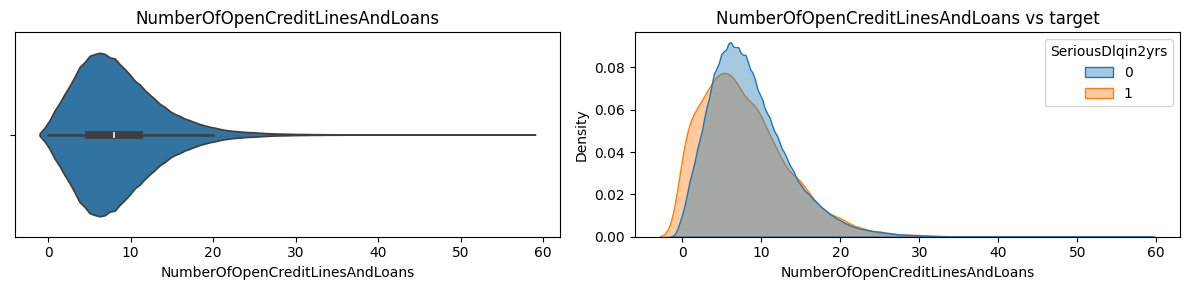

In [41]:
plot_feature(train_df, 'NumberOfOpenCreditLinesAndLoans')

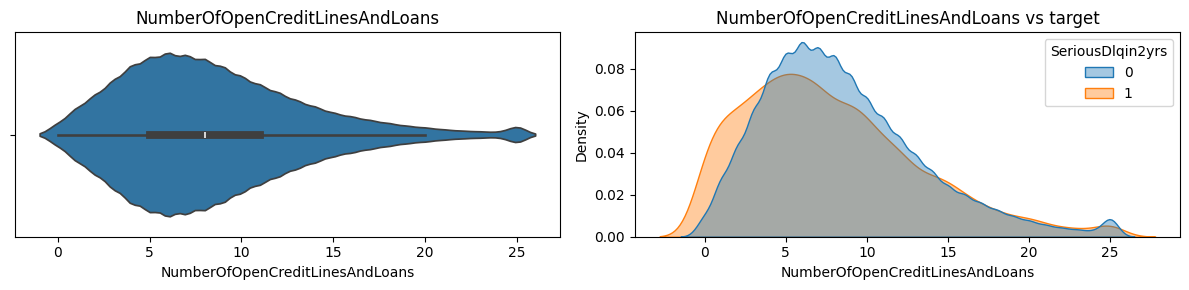

In [42]:
col = 'NumberOfOpenCreditLinesAndLoans'

high = train_df[col].quantile(0.99)

buf_df = train_df.copy()
buf_df[col] = buf_df[col].clip(upper=high)

plot_feature(buf_df, col)

In [43]:
train_df = buf_df.copy()

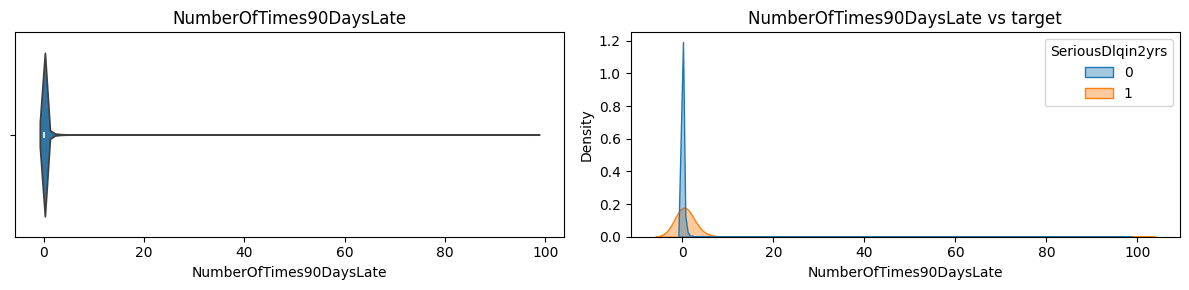

In [44]:
plot_feature(train_df, 'NumberOfTimes90DaysLate')

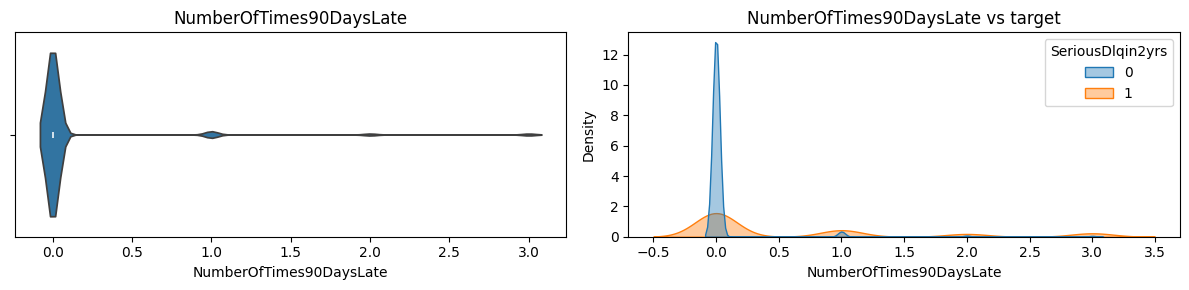

In [45]:
col = 'NumberOfTimes90DaysLate'

high = train_df[col].quantile(0.99)

buf_df = train_df.copy()
buf_df[col] = buf_df[col].clip(upper=high)

plot_feature(buf_df, col)

In [46]:
train_df = buf_df.copy()

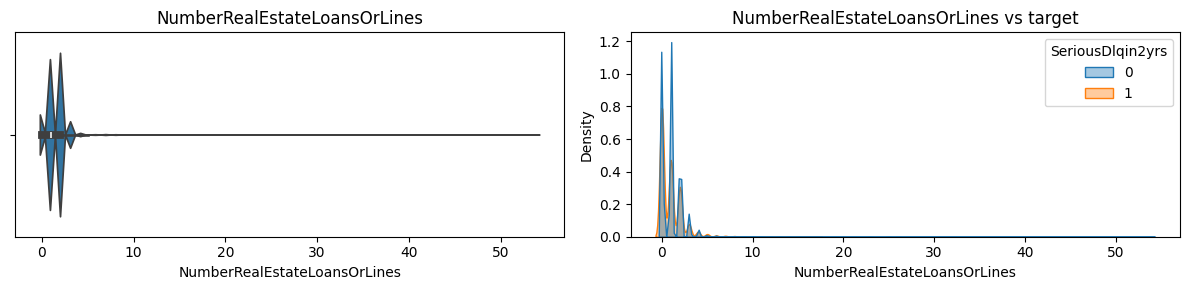

In [47]:
plot_feature(train_df, 'NumberRealEstateLoansOrLines')

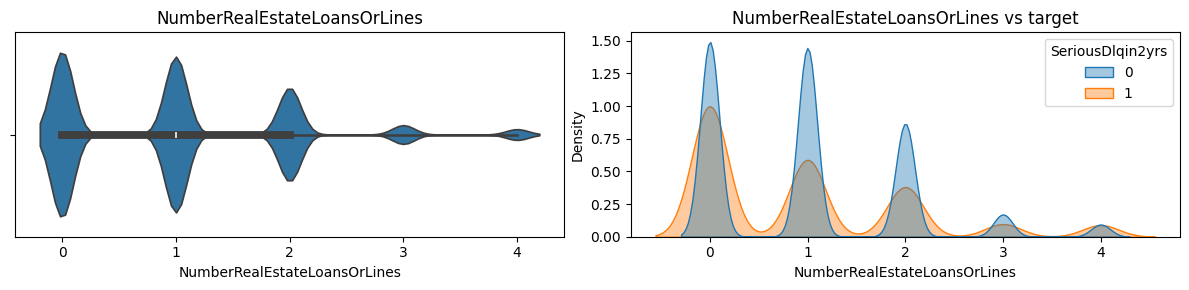

In [48]:
col = 'NumberRealEstateLoansOrLines'

high = train_df[col].quantile(0.99)

buf_df = train_df.copy()
buf_df[col] = buf_df[col].clip(upper=high)

plot_feature(buf_df, col)

In [49]:
train_df = buf_df.copy()

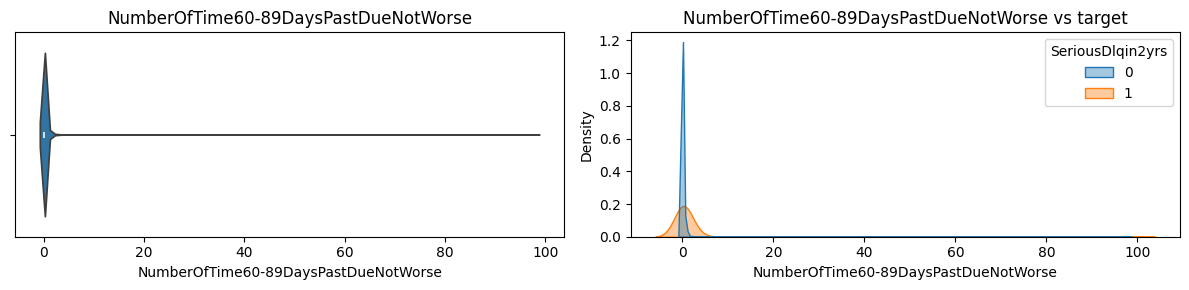

In [50]:
plot_feature(train_df, 'NumberOfTime60-89DaysPastDueNotWorse')

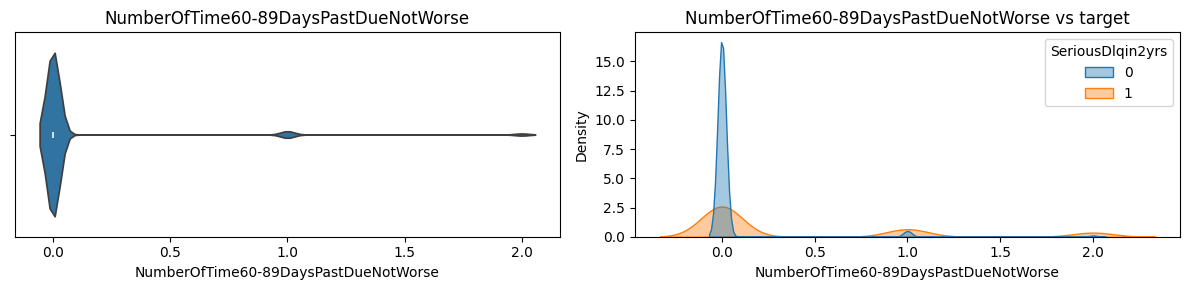

In [51]:
col = 'NumberOfTime60-89DaysPastDueNotWorse'

high = train_df[col].quantile(0.99)

buf_df = train_df.copy()
buf_df[col] = buf_df[col].clip(upper=high)

plot_feature(buf_df, col)

In [52]:
train_df = buf_df.copy()

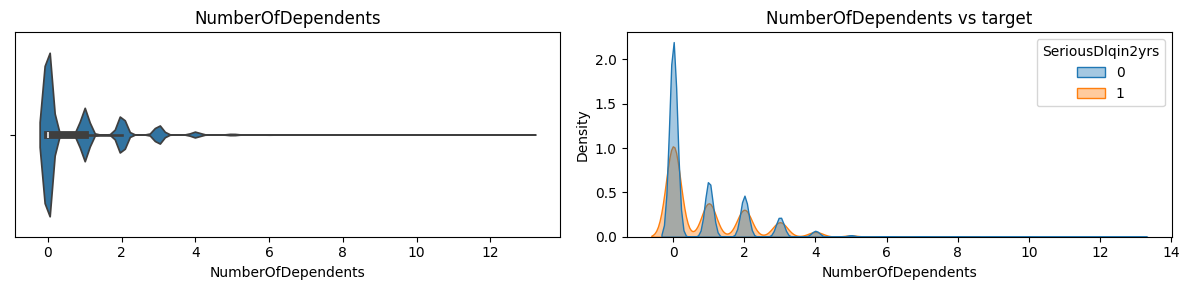

In [53]:
plot_feature(train_df, 'NumberOfDependents')

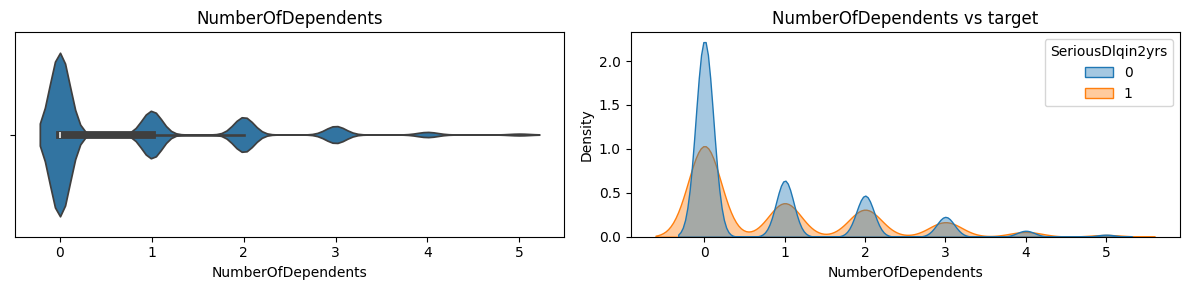

In [54]:
col = 'NumberOfDependents'

high = 5

buf_df = train_df.copy()
buf_df[col] = buf_df[col].clip(upper=high)

plot_feature(buf_df, col)

In [55]:
train_df = buf_df.copy()

### Матрица корреляции

In [56]:
int_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfOpenCreditLinesAndLoans', 
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse', 
    'NumberOfDependents',
    'NumberRealEstateLoansOrLines'
]

for col in int_cols:
    train_df[col] = train_df[col].astype(int)
    val_df[col] = val_df[col].astype(int) 
    test_df[col] = test_df[col].astype(int)

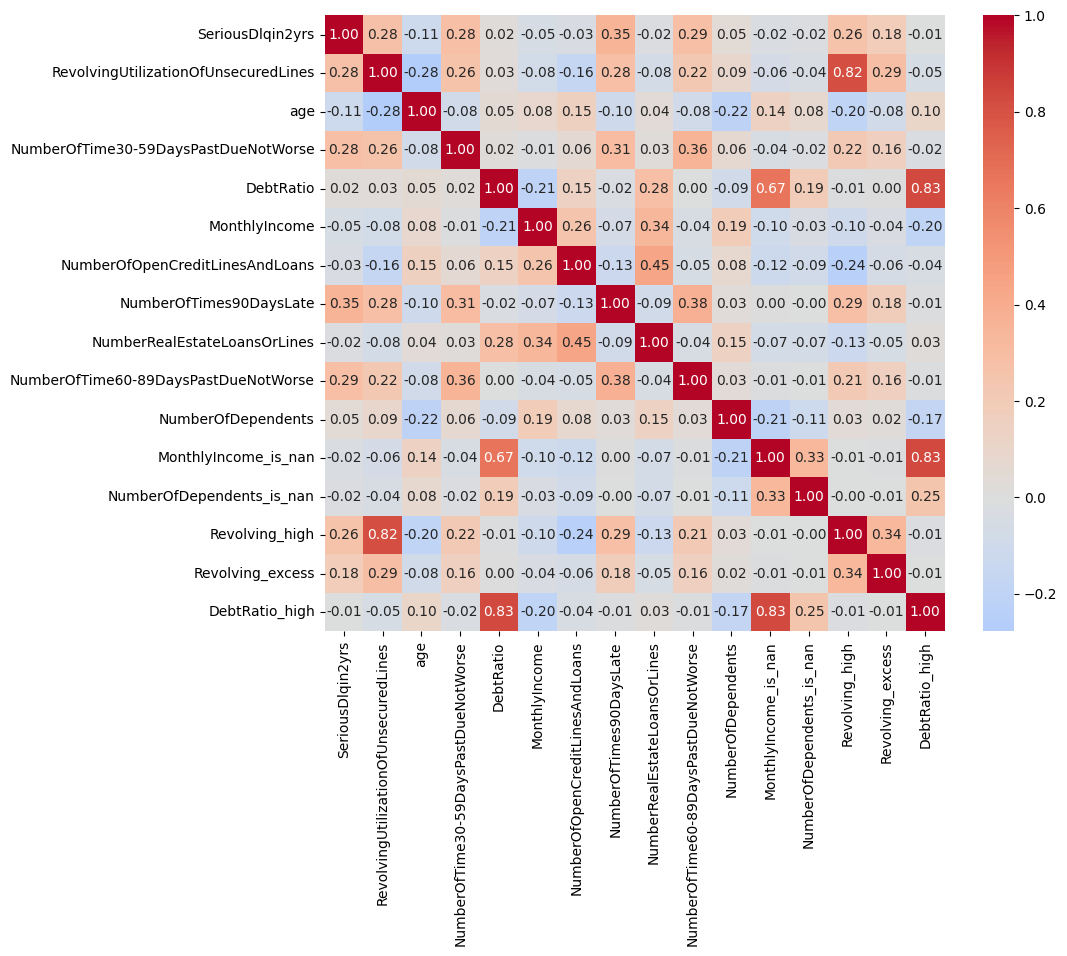

In [57]:
corr = train_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.show()

In [58]:
train_df.to_csv('data/base/train.csv', index=False)
val_df.to_csv('data/base/val.csv', index=False)
test_df.to_csv('data/base/test.csv', index=False)